In [2]:
%load_ext autoreload
%autoreload 2
import eq
import torch
import itertools
import pytorch_lightning as pl
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path(eq.__file__).parent.parent
results_dir = base_dir / 'results' / "AGU25"

## Data centric AI

In this notebook I experiement with data transforamtions to improve RECAST's performance.

Core to this approach is the recognition that earthquake catalogs are sparsely labelled. In this sense, to unlock the potential of AI driven approach we need to introduce approached to enrich the data.

Here are a few ideas I had in mind:

1. Superimpose seismicity on the catalog.
    - This is a simple approach to enrich the data. I beleive it is also principled in the sense that it is seismicity can unfold in many, effectively non-interaction seismic clusters. 
2. Removing Mc from the catalog.



 
 | Experiment Name          | Model                   | Training Schedule   |
 |--------------------------|-------------------------|---------------------|
 | Base                     | RECAST                  | Standard            |
 | Superimpose Seismicity   | RECAST                  | Train on augmented dataset |
 | Superimpose Seismicity   | RECAST                  | Pretrain on augmented dataset, then on full dataset |




In [10]:
!rm -rf /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/ANSS_MultiCatalog
catalog = eq.catalogs.ANSS_MultiCatalog(    
    num_sequences=5000,
    t_end_days=365,
    radius_kilometers=250,
    mag_completeness=4.5,
    minimum_mainshock_mag=6.5,
)

269149.91s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Generating the catalog...
Downloading/loading...


/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/eq/catalogs/anss.py:173: UserWarning: Using existing /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/raw/anss_global_catalog.csv
  warnings.warn(f"Using existing {filename}")
/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/eq/catalogs/anss.py:179: UserWarning: 248 NaN values found in catalog. Removing rows with NaN values.
  warnings.warn(


train


100%|██████████| 3000/3000 [00:04<00:00, 675.71it/s]


val


100%|██████████| 1000/1000 [00:01<00:00, 531.46it/s]


test


100%|██████████| 1000/1000 [00:01<00:00, 560.78it/s]


Success!
Catalog saved to /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/ANSS_MultiCatalog


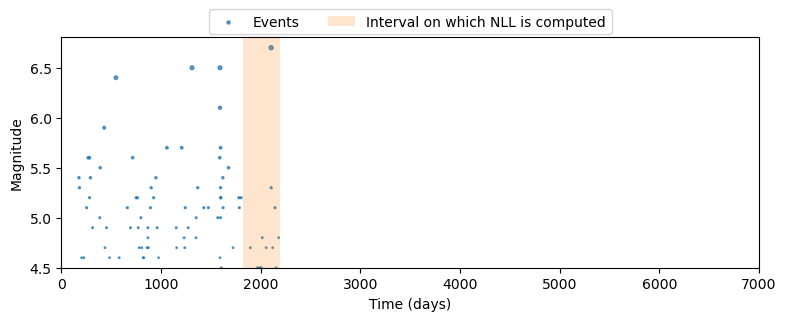

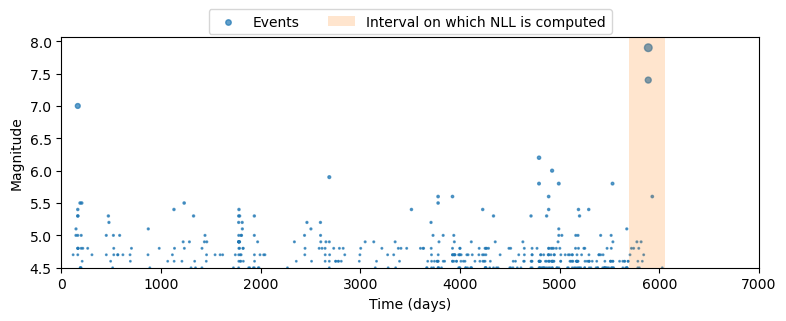

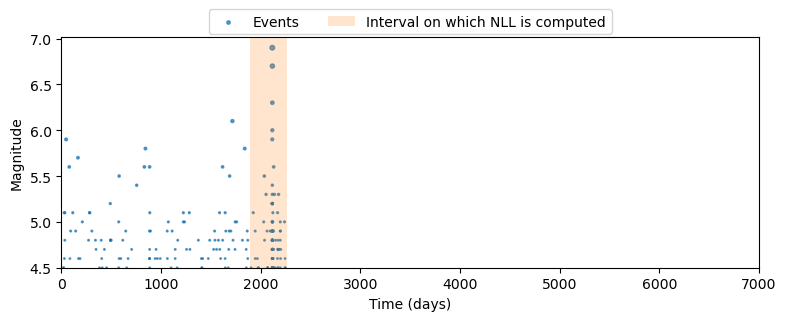

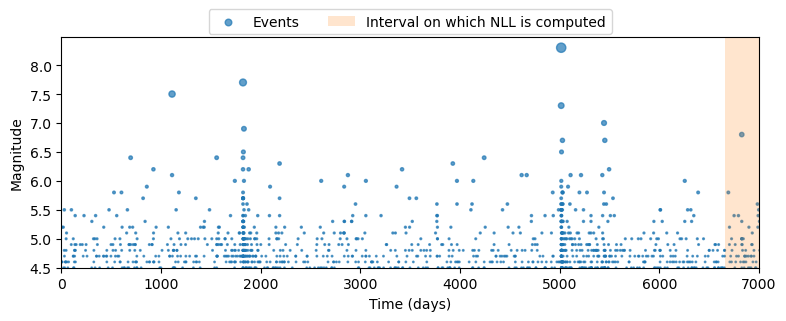

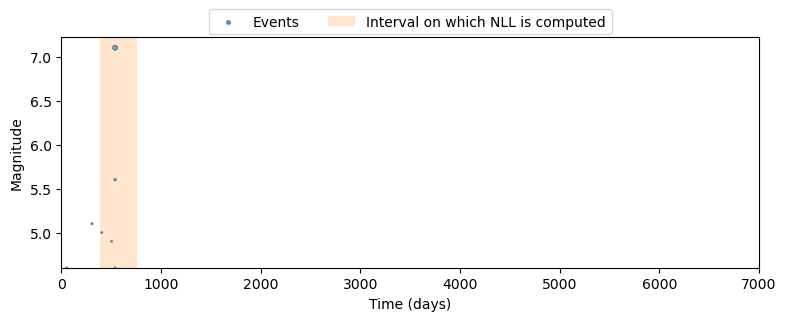

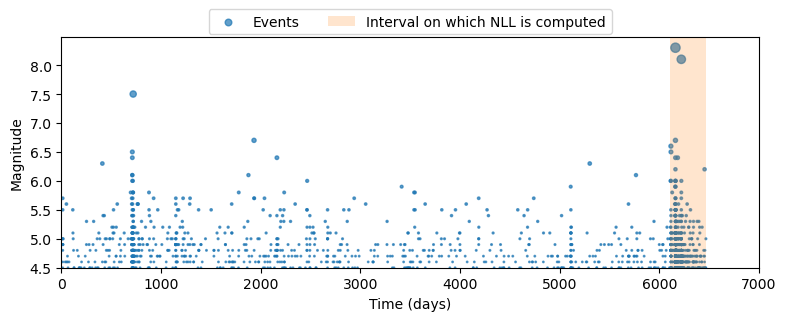

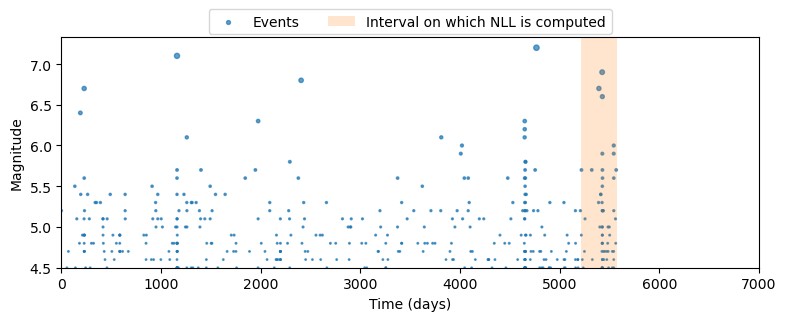

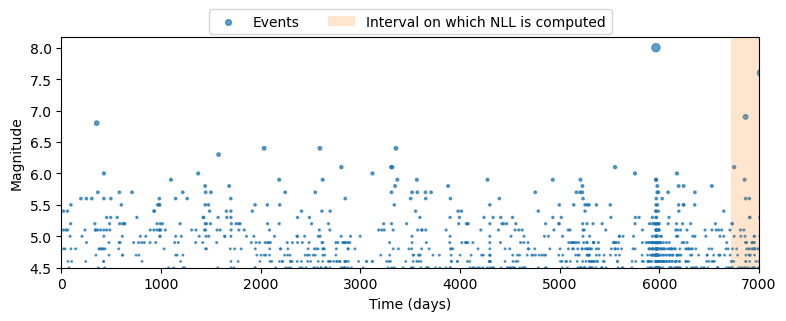

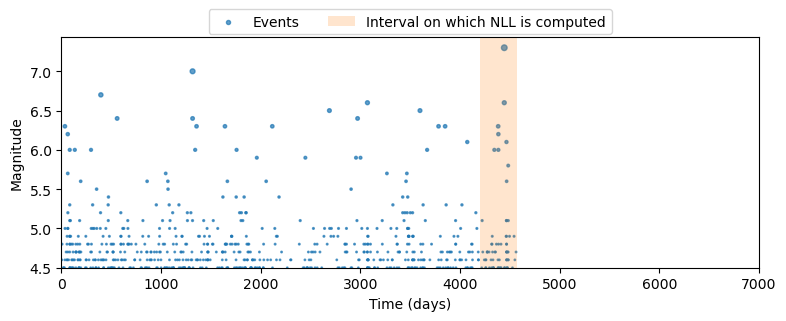

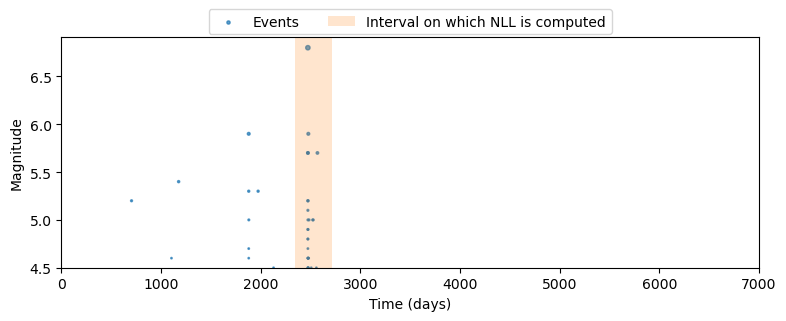

In [31]:
for i in range(10):
    ax = eq.visualization.visualize_sequence(catalog.train[i], show_nll=True)
    ax.set(xlim=(0, 7000))


As a simple starting point I impltement a simple jitter to the magnitudes of the earthquakes in the catalog.

In [32]:
augmentation_list = [
    ("jitter", {"key": "mag", "std": 0.1}),
    ("superimpose", {"seq_bank": catalog.train.sequences}),
    ("jitter_time", {"std": 1e-5}),
]

In [ ]:
all_augmentation_permutations = [
    eq.data.AugmentationCollator(augmentation_list) 
    for augmentation_list in itertools.permutations(augmentation_list)
]

In [46]:
base_train_dataloader = torch.utils.data.DataLoader(
    catalog.train,
    batch_size=100,
    shuffle=True,
    collate_fn = eq.data.Batch.from_list
)

augmented_train_dataloader = torch.utils.data.DataLoader(
    catalog.train,
    batch_size=100,
    shuffle=True,
    collate_fn=all_augmentation_permutations[0],
)

val_dataloader = catalog.val.get_dataloader(batch_size=100)


In [ ]:
# note that run experirment calls global variables
# catalog
# val_dataloader

def run_experiment(train_dataloader):
    # base model training
    checkpoint = pl.callbacks.ModelCheckpoint(monitor="total_val_loss")
    early_stopping = pl.callbacks.EarlyStopping(monitor="total_val_loss", patience=100)

    trainer = pl.Trainer(
        max_epochs=1000,
        callbacks=[checkpoint, early_stopping],
        log_every_n_steps=1,
    )
    
    # todo: set tau_mean? How to set it considering the superimpose augmentation?
    T = catalog.train[0].t_end
    N = torch.mean([len(seq) for seq in catalog.train])
    tau_mean = T/N
    
    model = eq.models.RecurrentTPP(
        tau_mean=tau_mean,
        learning_rate=1e-3,
    )

    trainer.fit(model, train_dataloader, val_dataloader)

    best_model_path = Path(checkpoint.best_model_path).parent.parent / "metrics.csv"
    metrics = pd.read_csv(best_model_path)
    metrics.plot.scatter(x="epoch", y="val_loss", s=1)

    return metrics

### Experiment 1: Base model training

In [ ]:
run_experiment(base_train_dataloader)

### Experiment 2: Augmented model training

In [ ]:
for augmentation in all_augmentation_permutations:
    augmented_train_dataloader = torch.utils.data.DataLoader(
        catalog.train,
        batch_size=100,
        shuffle=False,
        collate_fn=augmentation,
    )
    run_experiment(augmented_train_dataloader)

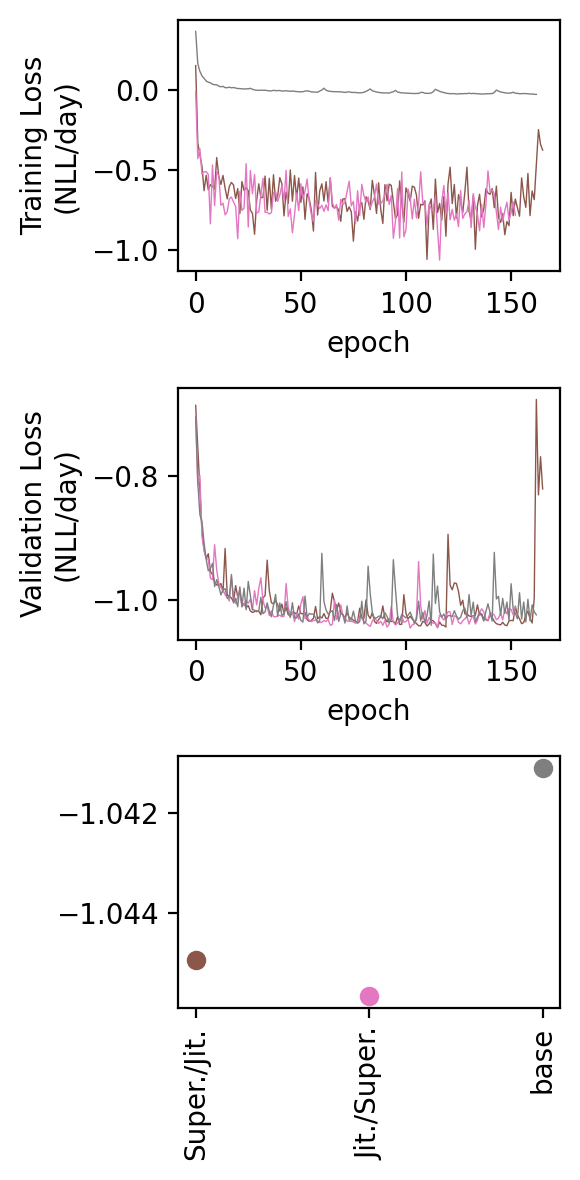

In [ ]:
version_list = [5,6,7]
fig, AX = plt.subplots(3,1, dpi=200, figsize=(3,6))

ax = AX[0]
for version in version_list:
    best_model_path = Path(f'lightning_logs/version_{version}/metrics.csv')
    metrics = pd.read_csv(best_model_path)
    metrics.dropna(subset=['train_loss']).plot.line(x='epoch', y='train_loss', linewidth=0.5, ax=ax, color=f'C{version%10}', label=f'version {version}')
ax.set(ylabel="Training Loss\n(NLL/day)")
ax.get_legend().remove()

ax = AX[1]
for version in version_list:
    best_model_path = Path(f'lightning_logs/version_{version}/metrics.csv')
    metrics = pd.read_csv(best_model_path)
    metrics.dropna(subset=['val_loss']).plot.line(x='epoch', y='val_loss', linewidth=0.5, ax=ax, color=f'C{version%10}', label=f'version {version}')
ax.set(ylabel="Validation Loss\n(NLL/day)")
ax.get_legend().remove()

ax = AX[2]
val_loss_list = []

for version in version_list:
    best_model_path = Path(f'lightning_logs/version_{version}/metrics.csv')
    metrics = pd.read_csv(best_model_path)
    ax.scatter(version, metrics.dropna(subset=['val_loss'])['val_loss'].values.min(), color=f'C{version%10}')

ax.set(
    xticks=version_list,
    xticklabels=[f"{version}" for version in ["Super./Jit.", "Jit./Super.", "base"]],
)
# rotate xticklabels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.savefig(results_dir / 'val_loss_scatter.png') 